# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [36]:
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [16]:
df = pd.read_csv("../data/states_edu.csv")
df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: Grade 4 Math

How many years of data are logged in our dataset? 

In [17]:
# @@@ 1
# Your Code
num_years = df['YEAR'].nunique()
print(num_years)

33


Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [18]:
# @@@ 2
michigan_avg = df[df['STATE'] == 'MICHIGAN']['AVG_MATH_4_SCORE'].mean()
ohio_avg = df[df['STATE'] == 'OHIO']['AVG_MATH_4_SCORE'].mean()
print("Michigan:", michigan_avg)
print("Ohio:", ohio_avg)

Michigan: 234.36363636363637
Ohio: 239.45454545454547


Find the average for your chosen test across all states in 2019

In [19]:
# @@@ 3
test_avg = df[df['YEAR'] == 2019]['AVG_MATH_4_SCORE'].mean()
print(test_avg)

239.9433962264151


For each state, find a maximum value for your chosen test score

In [11]:
# @@@ 4
max_state = df.groupby('STATE')['AVG_MATH_4_SCORE'].max()
print(max_state)

STATE
ALABAMA                 233.0
ALASKA                  237.0
ARIZONA                 240.0
ARKANSAS                240.0
CALIFORNIA              235.0
COLORADO                247.0
CONNECTICUT             245.0
DELAWARE                243.0
DISTRICT_OF_COLUMBIA    235.0
DODEA                   250.0
FLORIDA                 246.0
GEORGIA                 240.0
HAWAII                  243.0
IDAHO                   242.0
ILLINOIS                239.0
INDIANA                 249.0
IOWA                    246.0
KANSAS                  248.0
KENTUCKY                242.0
LOUISIANA               234.0
MAINE                   246.0
MARYLAND                247.0
MASSACHUSETTS           253.0
MICHIGAN                238.0
MINNESOTA               253.0
MISSISSIPPI             241.0
MISSOURI                241.0
MONTANA                 244.0
NATIONAL                242.0
NEBRASKA                246.0
NEVADA                  237.0
NEW_HAMPSHIRE           253.0
NEW_JERSEY              249.0
NEW_

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [26]:
# @@@ 5
df['Instruction_share'] = df['INSTRUCTION_EXPENDITURE'] / df['TOTAL_EXPENDITURE']
df[['STATE', 'YEAR', 'Instruction_share']].head()
df['Spending_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL']

I created Instruction_share, the fraction of total expenditures that goes to instruction. A higher share might suggest that a state prioritizes education, and a share lets me compare states of different sizes. I also created Spending_per_student, which is total expenditure divided by enrollment. States that spend more per student might be able to afford more teachers and better learning materials, and dividing by enrollment keeps large states from looking like bigger spenders just because they have more students.

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

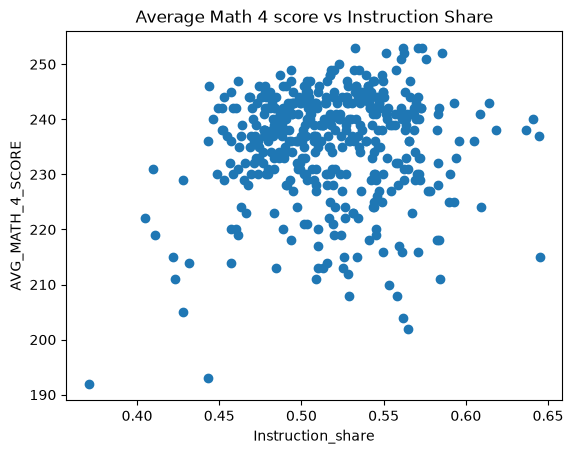

In [24]:
# @@@ 6
plt.scatter(df["Instruction_share"], df["AVG_MATH_4_SCORE"])
plt.xlabel("Instruction_share")
plt.ylabel("AVG_MATH_4_SCORE")
plt.title("Average Math 4 score vs Instruction Share")
plt.show()

Each point is one state in one year. Most points are bunched between an instruction share of about 0.45 and 0.58, with Grade 4 math scores mostly between about 230 and 245. There does not seem to be a clear upward or downward trend across the whole plot, so instruction share alone may not explain much of the difference in scores. The few points with the lowest shares (around 0.37 to 0.43) tend to have lower scores, but there are so few of them that it is hard to say if that means anything. Points with higher shares (above 0.60) have scores that range from about 215 to 240.


**Visualization 2**

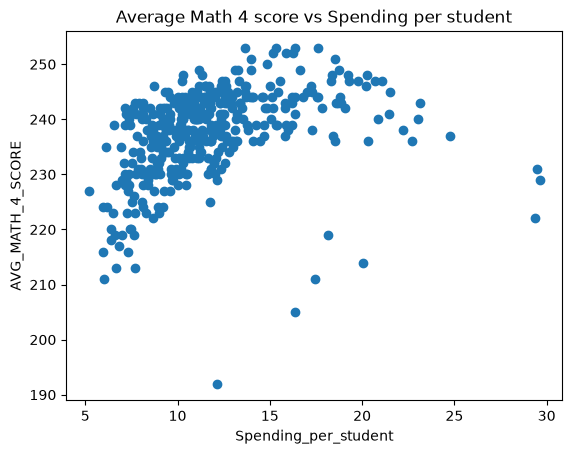

In [27]:
# @@@ 7
plt.scatter(df["Spending_per_student"], df["AVG_MATH_4_SCORE"])
plt.xlabel("Spending_per_student")
plt.ylabel("AVG_MATH_4_SCORE")
plt.title("Average Math 4 score vs Spending per student")
plt.show()

Each point is one state in one year. In this plot, states with lower spending per student (about 5 to 10) tend to have lower Grade 4 math scores, and scores seem to rise as spending per student increases up to about 15. After that, the increase seems to level off, and scores are more spread out at higher spending levels (above 20). This is a clearer pattern than in Visualization 1, where the points looked more like a blob. Overall, the plot might suggest that spending per student is related to Grade 4 math scores, at least at lower spending levels.

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [28]:
from sklearn.model_selection import train_test_split
data = df[['Instruction_share', 'Spending_per_student', 'AVG_MATH_4_SCORE']].dropna()

In [29]:
# @@@ 8

X = data[['Instruction_share', 'Spending_per_student']]
y = data['AVG_MATH_4_SCORE']

In [30]:
# @@@ 9 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state=42)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [31]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression


In [32]:
# @@@ 11
# create your model here
model = LinearRegression()

In [34]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[35.35, 0.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Instruction_share','Spending_per_student']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,211.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [35]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [37]:
# @@@ 12
np.mean(np.abs(model.predict(X_test)-y_test))

np.float64(5.978701653338706)

We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

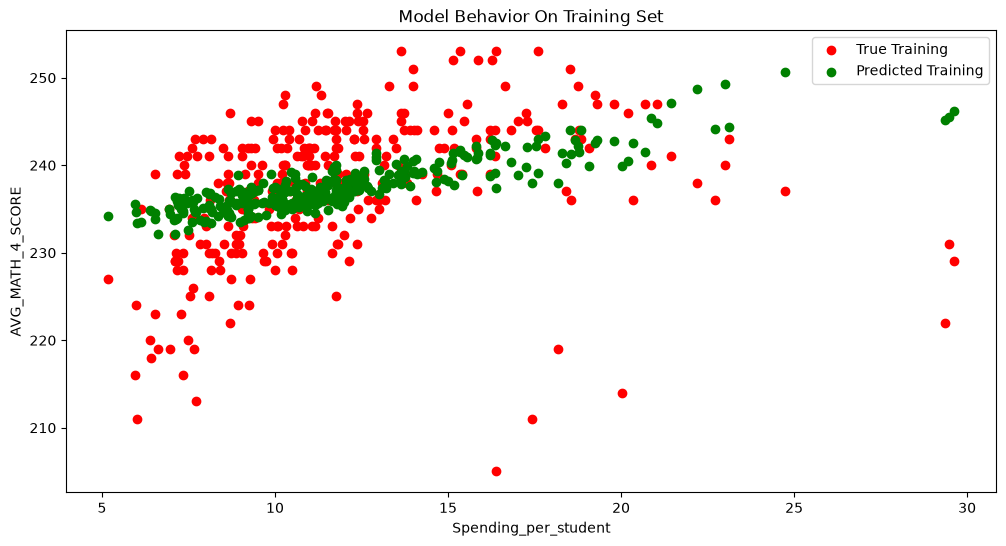

In [38]:
# @@@ 13

col_name = 'Spending_per_student'


f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('AVG_MATH_4_SCORE')
plt.title("Model Behavior On Training Set")

Text(0.5, 1.0, 'Model Behavior on Testing Set')

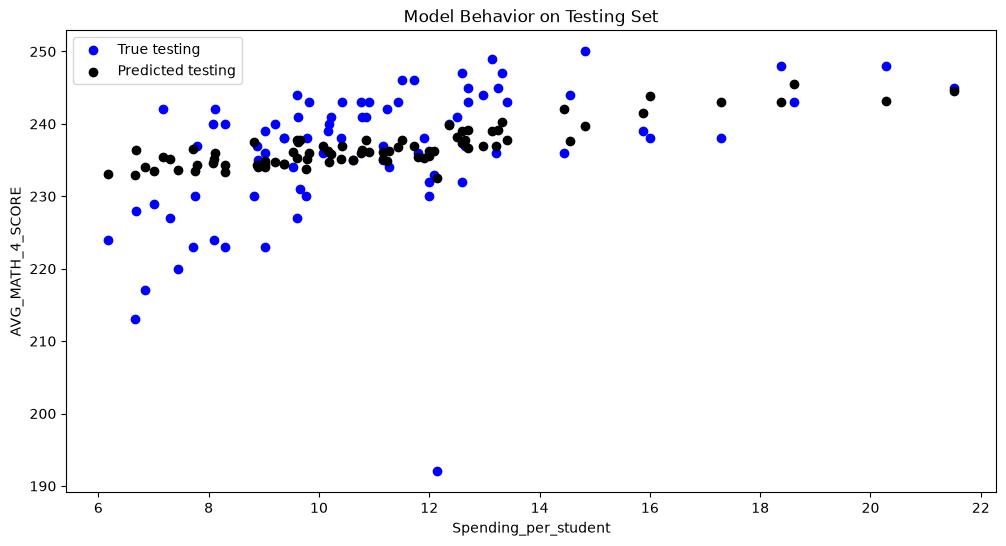

In [40]:
# @@@ 14


col_name = 'Spending_per_student'


f = plt.figure(figsize=(12,6))
plt.scatter(X_test[col_name], y_test, color = "blue")
plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel('AVG_MATH_4_SCORE')
plt.title("Model Behavior on Testing Set")